# Posterior Overlay and Importance Sampling (Clean)

这个 notebook 做三件事：
1. 读取 `joint_clean.nc`（Euclid clean）和 `joint_PDSPL_only_w0waCDM.h5`（LSST/PDSPL）。
2. 用 PDSPL 后验在 `(Omegam, w0, wa)` 上对 Euclid clean 做 importance reweight，得到新的 cosmology 约束。
3. 把 `dspl_clean.nc / lens_kin_clean.nc / quasar_clean.nc / sne_clean.nc / PDSPL(h5)` 后验画在同一张 corner 图上。


Using joint clean: /mnt/lustre/tianli/LensedUniverse_result/joint_clean.nc
Using PDSPL h5: /users/tianli/LensedUniverse/data/joint_PDSPL_only_w0waCDM.h5
Using DSPL clean: /mnt/lustre/tianli/LensedUniverse_result/dspl_clean.nc
Using Lens+kin clean: /mnt/lustre/tianli/LensedUniverse_result/lens_kin_clean.nc
Using Quasar clean: /mnt/lustre/tianli/LensedUniverse_result/quasar_clean.nc
Using SNe clean: /mnt/lustre/tianli/LensedUniverse_result/sne_clean.nc


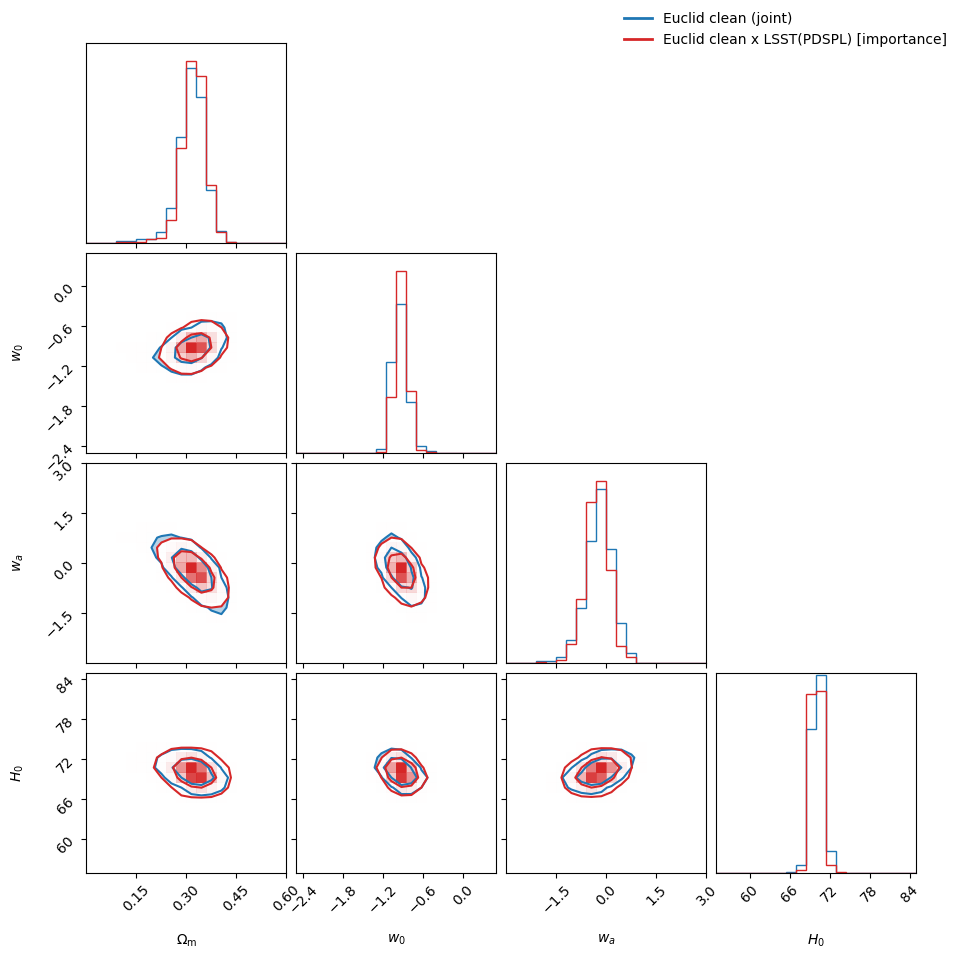

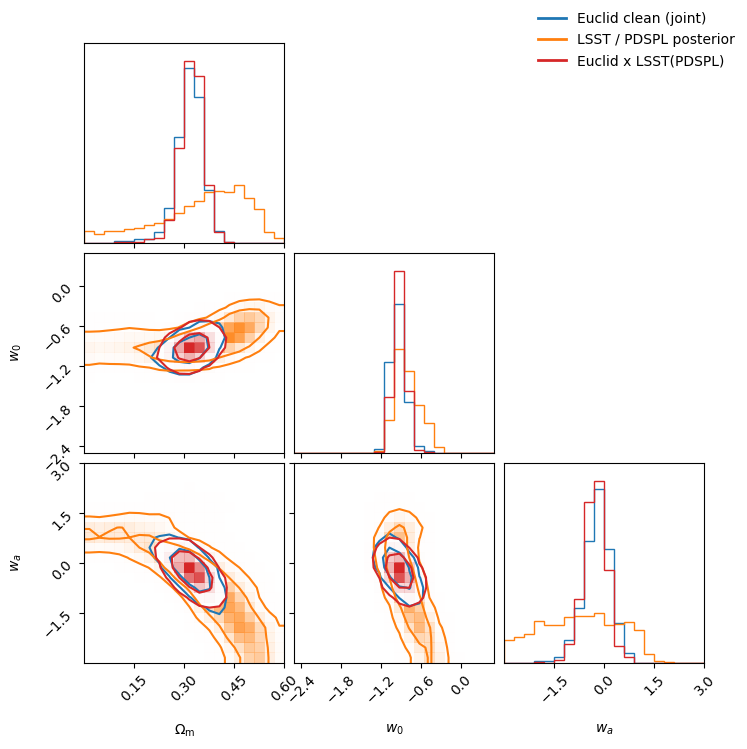

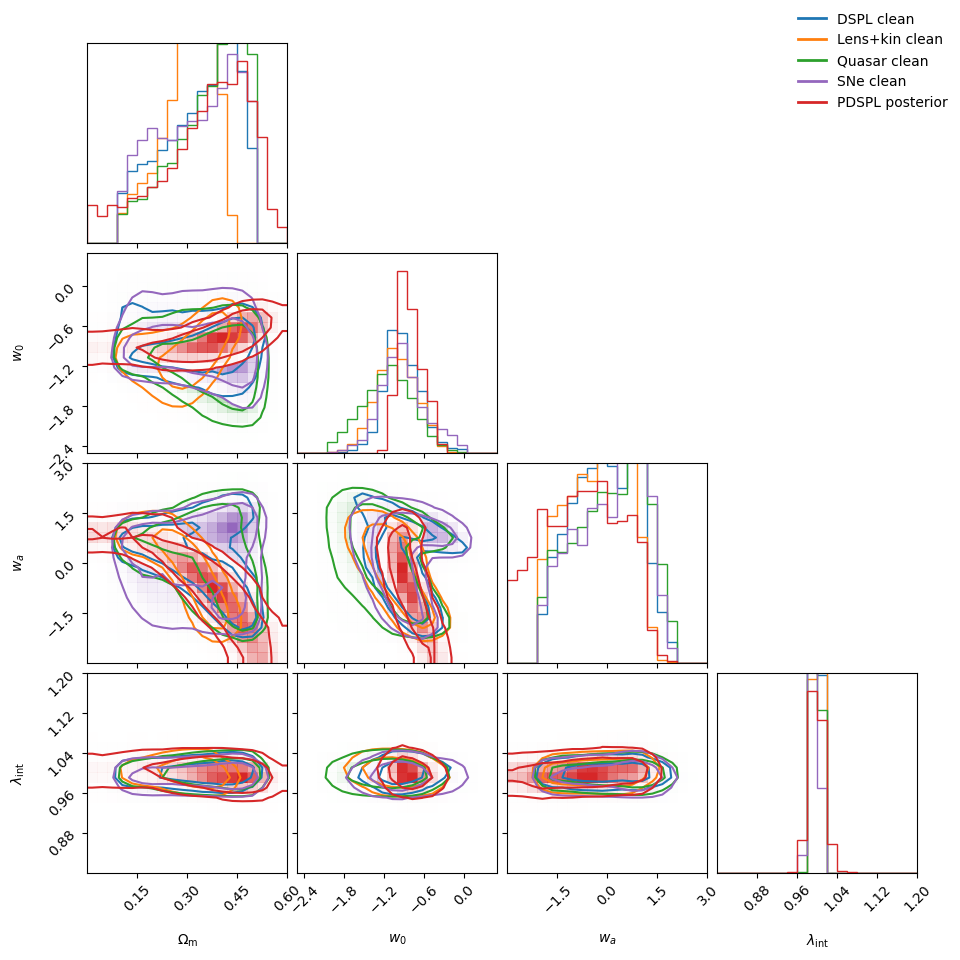

Saved: result/joint_clean_importance_cosmo_4d.png
Saved: result/joint_clean_importance_cosmo_4d.pdf
Saved: result/joint_clean_lsst_euclid_cosmo_3d_compare.png
Saved: result/joint_clean_lsst_euclid_cosmo_3d_compare.pdf
Saved: result/clean_probes_plus_pdspl_corner.png
Saved: result/clean_probes_plus_pdspl_corner.pdf


In [1]:
import os
from pathlib import Path

import arviz as az
import numpy as np
import pandas as pd
import corner
import matplotlib.pyplot as plt
import emcee
from scipy.stats import gaussian_kde

# -------------------------------
# Paths and reproducibility
# -------------------------------
SEED = 42
rng = np.random.default_rng(SEED)

workdir = Path.cwd()
if not (workdir / 'hmc_scripts').exists():
    workdir = Path('/users/tianli/LensedUniverse')
os.chdir(workdir)

RESULT_DIR = Path(os.environ.get('SLCOSMO_RESULT_DIR', '/mnt/lustre/tianli/LensedUniverse_result'))
FIG_DIR = Path('result')
FIG_DIR.mkdir(parents=True, exist_ok=True)


def first_existing(candidates, label):
    for p in candidates:
        if p.exists():
            return p
    cand_msg = '\n'.join([f'  - {c}' for c in candidates])
    raise FileNotFoundError(f'Cannot find {label}. Checked:\n{cand_msg}')


# -------------------------------
# Input files
# -------------------------------
joint_clean_path = first_existing(
    [
        RESULT_DIR / 'joint_clean.nc',
        workdir / 'result' / 'smoke_nc' / 'joint_clean.nc',
    ],
    'joint_clean.nc',
)

probe_paths = {
    'DSPL clean': first_existing([RESULT_DIR / 'dspl_clean.nc'], 'dspl_clean.nc'),
    'Lens+kin clean': first_existing([RESULT_DIR / 'lens_kin_clean.nc'], 'lens_kin_clean.nc'),
    'Quasar clean': first_existing([RESULT_DIR / 'quasar_clean.nc'], 'quasar_clean.nc'),
    'SNe clean': first_existing([RESULT_DIR / 'sne_clean.nc'], 'sne_clean.nc'),
}

pdspl_h5_path = first_existing(
    [
        workdir / 'data' / 'joint_PDSPL_only_w0waCDM.h5',
        workdir / 'data' / 'lsst_y10_w0waCDM.h5',
        RESULT_DIR / 'joint_PDSPL_only_w0waCDM.h5',
        RESULT_DIR / 'lsst_y10_w0waCDM.h5',
        workdir / 'joint_PDSPL_only_w0waCDM.h5',
        workdir / 'lsst_y10_w0waCDM.h5',
    ],
    'joint_PDSPL_only_w0waCDM.h5 (or lsst_y10_w0waCDM.h5)',
)

print('Using joint clean:', joint_clean_path)
print('Using PDSPL h5:', pdspl_h5_path)
for k, v in probe_paths.items():
    print(f'Using {k}: {v}')


# -------------------------------
# Helpers
# -------------------------------
def flatten_var(idata, var_name):
    if var_name not in idata.posterior:
        raise KeyError(f'Variable {var_name} not found in posterior.')
    arr = np.asarray(idata.posterior[var_name]).reshape(-1)
    return arr


def extract_matrix_from_idata(idata, vars_in_order):
    cols = [flatten_var(idata, v) for v in vars_in_order]
    mat = np.column_stack(cols)
    mask = np.isfinite(mat).all(axis=1)
    mat = mat[mask]
    if mat.shape[0] == 0:
        raise RuntimeError(f'No finite samples left for vars={vars_in_order}')
    return mat


def downsample_rows(x, n_max=50000, random_state=None):
    if x.shape[0] <= n_max:
        return x
    rr = np.random.default_rng(random_state)
    idx = rr.choice(x.shape[0], size=n_max, replace=False)
    return x[idx]


# -------------------------------
# Load posteriors
# -------------------------------
idata_joint_clean = az.from_netcdf(joint_clean_path)

# Euclid clean cosmology samples: Omegam, w0, wa, h0
joint_cosmo_vars = ['Omegam', 'w0', 'wa', 'h0']
joint_cosmo = extract_matrix_from_idata(idata_joint_clean, joint_cosmo_vars)
joint_cosmo = downsample_rows(joint_cosmo, n_max=120000, random_state=SEED)

# PDSPL/LSST posterior from emcee backend
backend = emcee.backends.HDFBackend(str(pdspl_h5_path), read_only=True)
raw = backend.get_chain(flat=True, discard=400, thin=100)
if raw.shape[1] < 5:
    raise RuntimeError(f'Expected >=5 columns in PDSPL chain, got shape={raw.shape}')

columns = [
    r'$\Omega_{\rm m}$',
    r'$w_0$',
    r'$w_{\rm a}$',
    r'$\overline{\lambda}_{\rm int}$',
    r'$\overline{\gamma}_{\rm pl}$',
]
df_pdspl = pd.DataFrame(raw[:, :5], columns=columns)

pdspl_cosmo = df_pdspl[[r'$\Omega_{\rm m}$', r'$w_0$', r'$w_{\rm a}$']].to_numpy()
pdspl_lambda = df_pdspl[r'$\overline{\lambda}_{\rm int}$'].to_numpy()

mask_p = np.isfinite(pdspl_cosmo).all(axis=1) & np.isfinite(pdspl_lambda)
pdspl_cosmo = pdspl_cosmo[mask_p]
pdspl_lambda = pdspl_lambda[mask_p]

pdspl_cosmo = downsample_rows(pdspl_cosmo, n_max=120000, random_state=SEED)


# -------------------------------
# Importance sampling (Euclid clean x PDSPL posterior in Omegam,w0,wa)
# -------------------------------
# Use KDE over PDSPL posterior as an effective external likelihood in (Omegam,w0,wa),
# and reweight Euclid clean samples. h0 is carried through by joint correlations.
kde = gaussian_kde(pdspl_cosmo.T)
logw = kde.logpdf(joint_cosmo[:, :3].T)
logw = logw - np.max(logw)
weights = np.exp(logw)
weights /= np.sum(weights)

n_is = min(100000, joint_cosmo.shape[0])
idx_is = rng.choice(joint_cosmo.shape[0], size=n_is, replace=True, p=weights)
joint_cosmo_is = joint_cosmo[idx_is]

n_plot = min(80000, joint_cosmo.shape[0], pdspl_cosmo.shape[0], joint_cosmo_is.shape[0])
idx_joint = rng.choice(joint_cosmo.shape[0], size=n_plot, replace=False)
idx_pdspl = rng.choice(pdspl_cosmo.shape[0], size=n_plot, replace=False)
idx_is_plot = rng.choice(joint_cosmo_is.shape[0], size=n_plot, replace=False)

joint_plot = joint_cosmo[idx_joint]
pdspl_plot = pdspl_cosmo[idx_pdspl]
joint_is_plot = joint_cosmo_is[idx_is_plot]


# -------------------------------
# Figure 1: 4D cosmology (Euclid clean vs Euclid+PDSPL importance)
# -------------------------------
labels_4d = [r'$\Omega_{\rm m}$', r'$w_0$', r'$w_a$', r'$H_0$']
ranges_4d = ((0.0, 0.6), (-2.5, 0.5), (-3.0, 3.0), (55.0, 85.0))

fig1 = corner.corner(
    joint_plot,
    labels=labels_4d,
    color='C0',
    show_titles=False,
    range=ranges_4d,
    smooth=0.6,
    plot_datapoints=False,
    fill_contours=True,
    hist_kwargs=dict(density=True),
    levels=[0.68, 0.95],
)

corner.corner(
    joint_is_plot,
    fig=fig1,
    color='C3',
    show_titles=False,
    range=ranges_4d,
    smooth=0.8,
    plot_datapoints=False,
    fill_contours=False,
    hist_kwargs=dict(density=True),
    levels=[0.68, 0.95],
)

handles1 = [
    plt.Line2D([], [], color='C0', lw=2),
    plt.Line2D([], [], color='C3', lw=2),
]
fig1.legend(handles1, ['Euclid clean (joint)', 'Euclid clean x LSST(PDSPL) [importance]'], loc='upper right', frameon=False)

out1_png = FIG_DIR / 'joint_clean_importance_cosmo_4d.png'
out1_pdf = FIG_DIR / 'joint_clean_importance_cosmo_4d.pdf'
fig1.savefig(out1_png, dpi=220, bbox_inches='tight')
fig1.savefig(out1_pdf, bbox_inches='tight')
plt.show()


# -------------------------------
# Figure 2: 3D cosmology comparison (retain LSST vs Euclid comparison)
# -------------------------------
labels_3d = [r'$\Omega_{\rm m}$', r'$w_0$', r'$w_a$']
ranges_3d = ((0.0, 0.6), (-2.5, 0.5), (-3.0, 3.0))

fig2 = corner.corner(
    joint_plot[:, :3],
    labels=labels_3d,
    color='C0',
    show_titles=False,
    range=ranges_3d,
    smooth=0.6,
    plot_datapoints=False,
    fill_contours=True,
    hist_kwargs=dict(density=True),
    levels=[0.68, 0.95],
)

corner.corner(
    pdspl_plot,
    fig=fig2,
    color='C1',
    show_titles=False,
    range=ranges_3d,
    smooth=0.8,
    plot_datapoints=False,
    fill_contours=False,
    hist_kwargs=dict(density=True),
    levels=[0.68, 0.95],
)

corner.corner(
    joint_is_plot[:, :3],
    fig=fig2,
    color='C3',
    show_titles=False,
    range=ranges_3d,
    smooth=0.8,
    plot_datapoints=False,
    fill_contours=False,
    hist_kwargs=dict(density=True),
    levels=[0.68, 0.95],
)

handles2 = [
    plt.Line2D([], [], color='C0', lw=2),
    plt.Line2D([], [], color='C1', lw=2),
    plt.Line2D([], [], color='C3', lw=2),
]
fig2.legend(handles2, ['Euclid clean (joint)', 'LSST / PDSPL posterior', 'Euclid x LSST(PDSPL)'], loc='upper right', frameon=False)

out2_png = FIG_DIR / 'joint_clean_lsst_euclid_cosmo_3d_compare.png'
out2_pdf = FIG_DIR / 'joint_clean_lsst_euclid_cosmo_3d_compare.pdf'
fig2.savefig(out2_png, dpi=220, bbox_inches='tight')
fig2.savefig(out2_pdf, bbox_inches='tight')
plt.show()


# -------------------------------
# Figure 3: 5-way overlay corner (4 clean probes + PDSPL)
# -------------------------------
# Dimensions: Omegam, w0, wa, lambda_int
# For nc files, use lambda_mean as lambda_int proxy at population level.
labels_5 = [r'$\Omega_{\rm m}$', r'$w_0$', r'$w_a$', r'$\lambda_{\rm int}$']
ranges_5 = ((0.0, 0.6), (-2.5, 0.5), (-3.0, 3.0), (0.8, 1.2))

probe_mats = {}
for probe_name, probe_path in probe_paths.items():
    idata_probe = az.from_netcdf(probe_path)
    needed = ['Omegam', 'w0', 'wa', 'lambda_mean']
    miss = [v for v in needed if v not in idata_probe.posterior]
    if miss:
        raise RuntimeError(f'{probe_name} missing vars: {miss}')
    m = extract_matrix_from_idata(idata_probe, needed)
    probe_mats[probe_name] = downsample_rows(m, n_max=70000, random_state=SEED)

pdspl_4d = np.column_stack([pdspl_cosmo, pdspl_lambda])
pdspl_4d = downsample_rows(pdspl_4d, n_max=70000, random_state=SEED)

colors = {
    'DSPL clean': 'C0',
    'Lens+kin clean': 'C1',
    'Quasar clean': 'C2',
    'SNe clean': 'C4',
    'PDSPL posterior': 'C3',
}

# Use DSPL as base filled contour, others line-only to keep readability.
fig3 = corner.corner(
    probe_mats['DSPL clean'],
    labels=labels_5,
    color=colors['DSPL clean'],
    show_titles=False,
    range=ranges_5,
    smooth=0.6,
    plot_datapoints=False,
    fill_contours=True,
    hist_kwargs=dict(density=True),
    levels=[0.68, 0.95],
)

for name in ['Lens+kin clean', 'Quasar clean', 'SNe clean']:
    corner.corner(
        probe_mats[name],
        fig=fig3,
        color=colors[name],
        show_titles=False,
        range=ranges_5,
        smooth=0.8,
        plot_datapoints=False,
        fill_contours=False,
        hist_kwargs=dict(density=True),
        levels=[0.68, 0.95],
    )

corner.corner(
    pdspl_4d,
    fig=fig3,
    color=colors['PDSPL posterior'],
    show_titles=False,
    range=ranges_5,
    smooth=0.8,
    plot_datapoints=False,
    fill_contours=False,
    hist_kwargs=dict(density=True),
    levels=[0.68, 0.95],
)

handles3 = [
    plt.Line2D([], [], color=colors['DSPL clean'], lw=2),
    plt.Line2D([], [], color=colors['Lens+kin clean'], lw=2),
    plt.Line2D([], [], color=colors['Quasar clean'], lw=2),
    plt.Line2D([], [], color=colors['SNe clean'], lw=2),
    plt.Line2D([], [], color=colors['PDSPL posterior'], lw=2),
]
labels3 = ['DSPL clean', 'Lens+kin clean', 'Quasar clean', 'SNe clean', 'PDSPL posterior']
fig3.legend(handles3, labels3, loc='upper right', frameon=False)

out3_png = FIG_DIR / 'clean_probes_plus_pdspl_corner.png'
out3_pdf = FIG_DIR / 'clean_probes_plus_pdspl_corner.pdf'
fig3.savefig(out3_png, dpi=220, bbox_inches='tight')
fig3.savefig(out3_pdf, bbox_inches='tight')
plt.show()

print('Saved:', out1_png)
print('Saved:', out1_pdf)
print('Saved:', out2_png)
print('Saved:', out2_pdf)
print('Saved:', out3_png)
print('Saved:', out3_pdf)
